In [1]:
import sys
from pathlib import Path

import torch.nn.functional as F
import torch
import tqdm as tqdm
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np

PROJECT_ROOT = ".."
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from datasets.eurosat import EuroSATDatasetLS
from utils.data_config import BigEarthNetInfo
from transformation.transformer import ToFloat, ZScoreNormalize


from models.moe_mae import MOEEncoder, MOEMAE, build_model
from models.vlm import VLM
from scripts.train_vlm_eurosat_hybrid import _build_train_loader, _configure_encoder_unfreeze, train, EuroSATHybridVLM, _prepare_batch

from utils.data_utils import load_model

import matplotlib.pyplot as plt
from utils.analysis_utils import to_rgb_landsat

%load_ext autoreload
%autoreload 2

/home/jordi.morales/Desktop/ELLIS Winter School/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [2]:
data_csv = "../data/eurosat-l/eurosat-val.txt"
data_path = "../data/eurosat-l/eurosat-l"

device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available() else "cpu"
    )

bigearth_transforms = transforms.Compose(
        [
            transforms.Resize((40, 40)),
            ToFloat(),
            ZScoreNormalize(
                BigEarthNetInfo.STATISTICS["mean"],
                BigEarthNetInfo.STATISTICS["std"],
            ),
        ]
    )

dataset = EuroSATDatasetLS(
        data_path,
        data_csv,
        transform=bigearth_transforms,
    )

dataloader = DataLoader(
        dataset,
        batch_size=16,
        persistent_workers=False,
        num_workers=2,
        shuffle=False,
        pin_memory=True,
    )


# Test Model

In [3]:
# General config
model_size = "S"
img_size = 40
patch_size = 4
in_channels = 7
checkpoint_path = "../weights/moe_mae_pretrained_S_best.pth"
temp_init = 0.07
batch_size = 16

In [4]:
# Init model
encoder = build_model(
        size=model_size,
        img_size=img_size,
        patch_size=patch_size,
        in_chans=in_channels,
    )
model = MOEMAE(encoder).to(device)
model = load_model(model, checkpoint_path, device)
encoder = model.encoder
encoder.eval()

text_encoder_str = "bert"
vlm = VLM(encoder, text_encoder_str, temp_init, device=device).to(device)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20117.97it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
## Load a single batch of images
data_iter = iter(dataloader)
imgs, labels = next(data_iter)
imgs = imgs.to(device)

# Load any text input (batch of input text)
input_txts = ["hello"]*batch_size

sim_mat = vlm(input_txts, imgs)

In [6]:
sim_mat.shape

torch.Size([16, 16])

# Train model

In [9]:
device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available() else "cpu"
    )
seed = 0
batch_size = 16
num_workers = 1
test_split_file = "../data/eurosat-l/eurosat-test.txt"
val_split_file = "../data/eurosat-l/eurosat-val.txt"
train_split_file = "../data/eurosat-l/eurosat-train.txt"
root_dir = "../data/eurosat-l/eurosat-l"
moe_ckpt = checkpoint_path
save_dir = "../weights"
save_name = "vlm_train_test"
amp = True

epochs = 1
lr = 1e-3
encoder_lr = 1e-5
weight_decay = 1e-2
clip_weight = 0.3
cls_weight = 1.0
label_smoothing = 0.0
prompt_template = "a multispectral satellite image showing {}"
log_every = 500
save_last = True

In [18]:
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

train_loader, class_names = _build_train_loader(
    root_dir=root_dir,
    split_file=train_split_file,
    batch_size=batch_size,
    num_workers=num_workers,
    seed=seed,
    num_samples=None,
    drop_last=True,
)
print(f"Loaded {len(class_names)} EuroSAT classes: {class_names}")

val_loader = None
if str(val_split_file).strip():
    val_loader, val_classes = _build_train_loader(
        root_dir=root_dir,
        split_file=val_split_file,
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
        num_samples=None,
        drop_last=False,
    )
    if list(val_classes) != list(class_names):
        raise ValueError("Train/val class ordering mismatch in EuroSAT folders.")
    print(f"Validation split enabled: {val_split_file}")

Loaded 10 EuroSAT classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Validation split enabled: ../data/eurosat-l/eurosat-val.txt


In [19]:
# Init model
encoder = build_model(size="S", img_size=40, patch_size=4, in_chans=7)
moe = MOEMAE(encoder).to(device)
moe = load_model(moe, moe_ckpt, device)
encoder = moe.encoder

text_encoder_str = "bert"
base_vlm = VLM(encoder, text_encoder_str, temp_init, device=device, freeze_encoders=True).to(device)
_configure_encoder_unfreeze(base_vlm, n_last_layers=0)

model = EuroSATHybridVLM(base_vlm=base_vlm, num_classes=len(class_names)).to(device)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8365.06it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
from ast import arg
epochs = 1

train(
    model,
    train_loader,
    val_loader,
    class_names=class_names,
    prompt_template=prompt_template,
    device=device,
    epochs=epochs,
    lr=lr,
    encoder_lr=encoder_lr,
    weight_decay=weight_decay,
    cls_weight=cls_weight,
    clip_weight=clip_weight,
    label_smoothing=label_smoothing,
    amp=amp,
    log_every=log_every,
    save_dir=save_dir,
    save_name=save_name,
    save_last=save_last,
    args=None
)

Epoch 0: 100%|██████████| 1012/1012 [01:03<00:00, 15.96it/s, R1_i2t_cls=0.875, R1_t2i_cls=1.000, best=inf, cls_acc=0.938, loss=0.4496, loss_clip=0.2222, loss_cls=0.3830]


Epoch 0 finished - train_loss=1.2501 val_loss=0.8512
Saved BEST checkpoint: ../weights/vlm_train_test_best.pt
Saved LAST checkpoint: ../weights/vlm_train_test_last.pt


EuroSATHybridVLM(
  (base_vlm): VLM(
    (image_encoder): MOEEncoder(
      (patch_proj): Conv2d(7, 144, kernel_size=(4, 4), stride=(4, 4))
      (week_proj): Linear(in_features=2, out_features=144, bias=True)
      (hour_proj): Linear(in_features=2, out_features=144, bias=True)
      (lat_proj): Linear(in_features=2, out_features=144, bias=True)
      (lon_proj): Linear(in_features=2, out_features=144, bias=True)
      (layers): ModuleList(
        (0): MoETransformerEncoderLayer(
          (norm1): LayerNorm((144,), eps=1e-05, elementwise_affine=True)
          (attn): GroupedQueryAttention(
            (q_proj): Linear(in_features=144, out_features=144, bias=True)
            (k_proj): Linear(in_features=144, out_features=72, bias=True)
            (v_proj): Linear(in_features=144, out_features=72, bias=True)
            (out_proj): Linear(in_features=144, out_features=144, bias=True)
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (proj_dropout): Dropout(p=0.0

# Retrieval

In [58]:
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

test_loader = None
if str(test_split_file).strip():
    test_loader, test_classes = _build_train_loader(
        root_dir=root_dir,
        split_file=test_split_file,
        batch_size=1,
        num_workers=num_workers,
        seed=seed,
        num_samples=None,
        drop_last=False,
    )

In [62]:
# Init model
encoder = build_model(size="S", img_size=40, patch_size=4, in_chans=7)
moe = MOEMAE(encoder).to(device)
moe = load_model(moe, moe_ckpt, device)
encoder = moe.encoder

text_encoder_str = "bert"
base_vlm = VLM(encoder, text_encoder_str, temp_init, device=device, freeze_encoders=True).to(device)
_configure_encoder_unfreeze(base_vlm, n_last_layers=0)

checkpoint = f"../weights/vlm_100epochs_best.pt"
model = EuroSATHybridVLM(base_vlm=base_vlm, num_classes=len(test_classes)).to(device)
model.load_state_dict(torch.load(checkpoint)["model_state"])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21473.97it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [ ]:
data = []
for batch in tqdm.tqdm(test_loader):
    imgs = batch[0]

    tb = _prepare_batch(
        batch,
        device=device,
        class_names=class_names,
        prompt_template=prompt_template,
    )
    _, _, image_embeddings = model.base_vlm.image_encoder(tb.imgs, tb.meta["week"], tb.meta["hour"], tb.meta["lat"], tb.meta["lon"])
    cls_image_embeddings = image_embeddings[:, 4]
    prj_image_embeddings = model.base_vlm.image_proj(cls_image_embeddings)
    image_tokens = F.normalize(prj_image_embeddings, dim=-1)
    data.append(image_tokens[0,:])

data = torch.stack(data)

  0%|          | 0/5400 [00:00<?, ?it/s]

100%|██████████| 5400/5400 [01:24<00:00, 63.85it/s]


In [63]:
input_text = "Hello"

text_embed = model.base_vlm.text_encoder.encode(input_text, normalize_embeddings=True, convert_to_tensor=True, device=device).clone()

distances = (data @ text_embed).abs()

In [100]:
values, idxs = distances.sort()

# Naming Experts

In [15]:
import json
res_file = "../results/eurosat_expert_naming.json"
with open(res_file, "rb") as f:
    naming_results = json.load(f)

In [17]:
naming_results.keys()

dict_keys(['config', 'query_bank', 'layers'])

In [23]:
naming_results["layers"]["1"].keys()

dict_keys(['names_raw', 'names_zscore', 'names_raw_prompt', 'names_zscore_prompt', 'top1_margin', 'top1_margin_zscore', 'uncertain_by_zscore_margin', 'names_with_uncertainty'])

In [26]:
naming_results["layers"]["1"]["names_raw"][0]

[['annual crop', 0.3392268717288971],
 ['herbaceous vegetation', 0.2890821397304535],
 ['permanent crop', 0.2536657452583313],
 ['vegetation', 0.20079730451107025],
 ['pasture', 0.1384437531232834],
 ['highway', 0.07611125707626343],
 ['bare soil', 0.05619952827692032],
 ['water', 0.036145973950624466],
 ['forest', 0.0256769061088562],
 ['river', 0.01662435755133629]]

In [27]:
naming_results["layers"]["1"]["names_zscore"][0]

[['annual crop', 1.6666754484176636],
 ['herbaceous vegetation', 1.344732403755188],
 ['permanent crop', 1.1173492670059204],
 ['vegetation', 0.7779192328453064],
 ['pasture', 0.3775920867919922],
 ['highway', -0.0225998368114233],
 ['bare soil', -0.15043866634368896],
 ['water', -0.27918803691864014],
 ['forest', -0.3464023768901825],
 ['river', -0.40452221035957336]]

In [28]:
naming_results["layers"]["1"]["names_raw_prompt"][0]

[['annual crop', 0.3392268717288971],
 ['herbaceous vegetation', 0.2890821397304535],
 ['permanent crop', 0.2536657452583313],
 ['vegetation', 0.20079730451107025],
 ['pasture', 0.1384437531232834],
 ['highway', 0.07611125707626343],
 ['bare soil', 0.05619952827692032],
 ['water', 0.036145973950624466],
 ['forest', 0.0256769061088562],
 ['river', 0.01662435755133629]]

# Text Retrieval

In [10]:
prompts = [
  "annual crop",
  "forest",
  "herbaceous vegetation",
  "highway",
  "industrial area",
  "pasture",
  "permanent crop",
  "residential area",
  "river",
  "sea or lake",
  "water",
  "vegetation",
  "bare soil"
]

In [11]:
all_texts = {
  "eurosat_synonyms": {
    "dense_residential": "dense urban neighborhood",
    "suburban_residential": "suburban residential area",
    "warehouses": "industrial buildings and warehouses",
    "road_corridor": "major road corridor",
    "cropland": "cultivated cropland",
    "orchards": "orchards or permanent crops",
    "grazing_land": "grazing pasture land",
    "green_cover": "vegetated land cover",
    "inland_water": "inland water body"
  },
  "eurosat_compositions": {
    "river_corridor": "river crossing vegetated land",
    "settlement_near_road": "residential area near a highway",
    "mixed_cropland": "mosaic of crop fields",
    "industrial_transport": "industrial area connected to transport infrastructure",
    "shoreline": "shoreline of a lake or sea",
    "forest_patchwork": "patches of forest and open vegetation"
  }
}

prompts = [i for i in all_texts["eurosat_compositions"].values()] + [i for i in all_texts["eurosat_synonyms"].values()]

In [12]:
prompts

['river crossing vegetated land',
 'residential area near a highway',
 'mosaic of crop fields',
 'industrial area connected to transport infrastructure',
 'shoreline of a lake or sea',
 'patches of forest and open vegetation',
 'dense urban neighborhood',
 'suburban residential area',
 'industrial buildings and warehouses',
 'major road corridor',
 'cultivated cropland',
 'orchards or permanent crops',
 'grazing pasture land',
 'vegetated land cover',
 'inland water body']

In [13]:
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [14]:
test_loader = None
if str(test_split_file).strip():
    test_loader, test_classes = _build_train_loader(
        root_dir=root_dir,
        split_file=test_split_file,
        batch_size=1,
        num_workers=num_workers,
        seed=seed,
        num_samples=None,
        drop_last=False,
    )

In [15]:
# Init model
encoder = build_model(size="S", img_size=40, patch_size=4, in_chans=7)
moe = MOEMAE(encoder).to(device)
moe = load_model(moe, moe_ckpt, device)
encoder = moe.encoder

text_encoder_str = "bert"
base_vlm = VLM(encoder, text_encoder_str, temp_init, device=device, freeze_encoders=True).to(device)
_configure_encoder_unfreeze(base_vlm, n_last_layers=0)

checkpoint = f"../weights/vlm_100epochs_best.pt"
model = EuroSATHybridVLM(base_vlm=base_vlm, num_classes=len(test_classes)).to(device)
model.load_state_dict(torch.load(checkpoint)["model_state"])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18770.95it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

0it [00:00, ?it/s]

['river crossing vegetated land' 'major road corridor' 'inland water body']


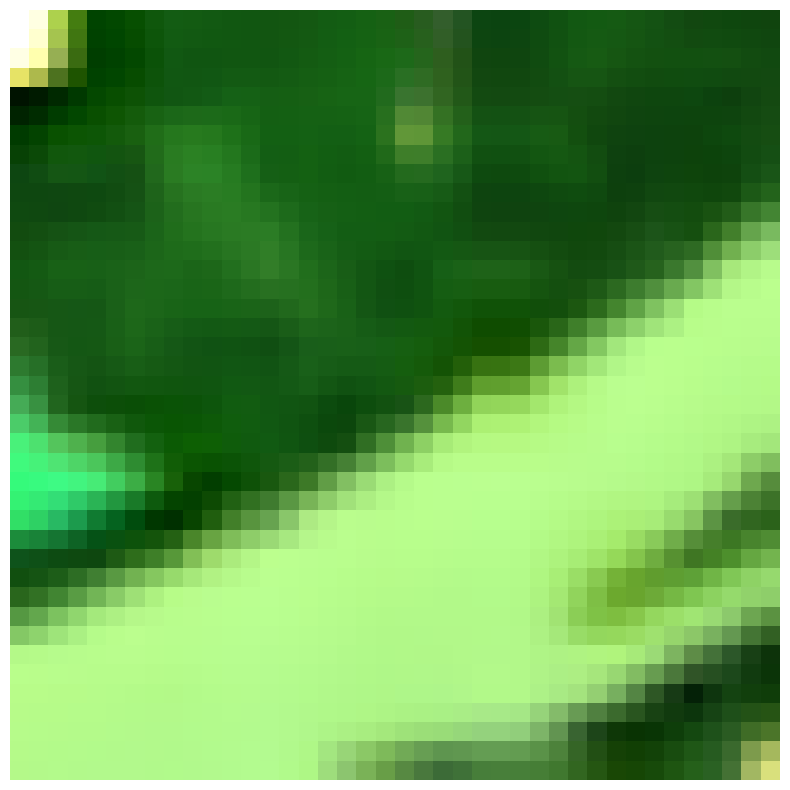

In [32]:
topk = 3
for i, batch in tqdm.tqdm(enumerate(test_loader)):
    orig_imgs = batch[0]

    tb = _prepare_batch(
        batch,
        device=device,
        class_names=test_classes,
        prompt_template=prompt_template,
    )
    image_tokens = model.base_vlm.encode_images(tb.imgs, tb.meta["week"], tb.meta["hour"], tb.meta["lat"], tb.meta["lon"]).squeeze(dim=0)

    if i == 0:
        # Compute text embeddings
        text_embeddings = []
        for prompt in prompts:
            text_embed = model.base_vlm.encode_text(prompt, normalize_embeddings=True)
            text_embeddings.append(text_embed)
        text_embeddings = torch.stack(text_embeddings)

        # COmpute distance between Prompts and query image. Get closest prompt
        distances = (text_embeddings @ image_tokens)
        sorted, idxs = distances.sort()
        sorted = reversed(sorted)
        idxs = reversed(idxs)
        closest_prompt = np.array(prompts)[idxs[:topk].cpu()]

        # Convert to RGB
        max = np.array([65454.0, 65454.0, 65330.308], dtype=np.float32)
        final_img = to_rgb_landsat(tb.imgs[0, :], max)

        # Plot image
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        ax.imshow(final_img)
        #ax.set_title(closest_prompt, fontsize=20)
        print(closest_prompt)
        ax.axis("off")
        break